In [4]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

In [ ]:
N_t = 10
N_ensembles = 5

# sample points on a sphere
def sample_points_on_sphere(n_points):
    phi = np.random.uniform(0, 2 * np.pi, n_points)
    costheta = np.random.uniform(-1, 1, n_points)
    theta = np.arccos(costheta)
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return x, y, z

n_points = 100

x, y, z = sample_points_on_sphere(n_points)


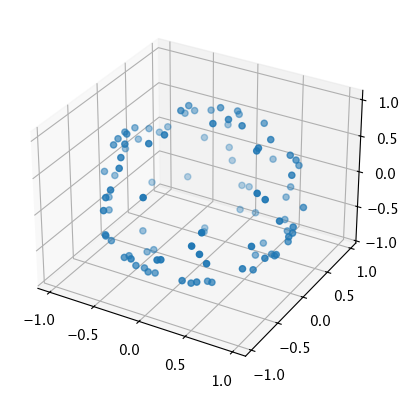

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(x, y, z)

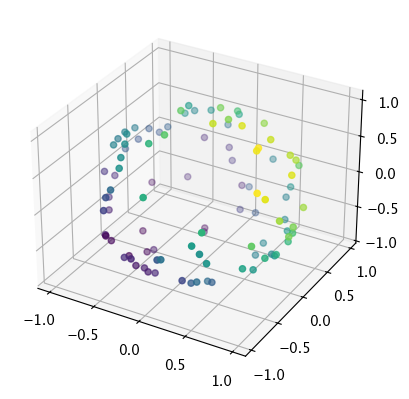

In [ ]:
def sample_function(x, y, z
    return np.sin(x) + np.cos(y) + np.sin(z) + np.random.normal(0, 0.1, size=x.shape)

wave_height = sample_function(x, y, z)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(x, y, z, c=wave_height, cmap="viridis")

In [ ]:
ds = xr.Dataset(
    {
        "x": (("point",), x),
        "y": (("point",), y),
        "z": (("point",), z),
        "wave_height": (("point",), wave_height),
    },
    coords={"grid_index": np.arange(n_points)},
)

ds.to_netcdf("sample_spherical_data.nc")


In [11]:
def create_dataset(n_t, n_ensembles, n_points):
    x, y, z = sample_points_on_sphere(n_points)
    
    for n in range(n_t):
        datasets = []
        for e in range(n_ensembles):
            wave_height = sample_function(x, y, z)
            ds = xr.Dataset(
                {
                    "x": (("point",), x),
                    "y": (("point",), y),
                    "z": (("point",), z),
                    "wave_height": (("point",), wave_height),
                },
                coords={"time": n, "ensemble": e, "grid_index": np.arange(n_points)},
            )
            
            datasets.append(ds)

    return xr.concat(datasets, dim="ensemble")

In [13]:
ds = create_dataset(N_t, N_ensembles, n_points)
ds

<xarray.Dataset> Size: 17kB
Dimensions:      (ensemble: 5, point: 100, grid_index: 100)
Coordinates:
  * ensemble     (ensemble) int64 40B 0 1 2 3 4
  * grid_index   (grid_index) int64 800B 0 1 2 3 4 5 6 ... 93 94 95 96 97 98 99
    time         int64 8B 9
Dimensions without coordinates: point
Data variables:
    x            (ensemble, point) float64 4kB -0.04199 -0.336 ... -0.7047
    y            (ensemble, point) float64 4kB 0.1762 0.9408 ... -0.06474 0.2234
    z            (ensemble, point) float64 4kB 0.9835 -0.04479 ... 0.6734
    wave_height  (ensemble, point) float64 4kB 1.691 0.2312 ... 0.6453 1.013